# K-Means Clustering From Scratch

In this notebook, we implement the K-Means clustering algorithm from scratch using NumPy.

We will:

- Understand the intuition behind clustering
- Implement each component of K-Means
- Visualize clustering results
- Explore the effect of different values of K
- Use the Elbow Method to select K

## What is Clustering?

Clustering is an unsupervised learning technique that groups similar data points together.

Unlike supervised learning, clustering does not require labeled data.

The goal of K-Means is to partition a dataset into K distinct clusters by minimizing the distance between points and their assigned cluster centroids.

## Objective Function

K-Means minimizes the average squared distance between each data point and its assigned centroid.

$$
J(c^{(1)},...,c^{(m)},\mu_1,...,\mu_K)
=
\frac{1}{m}
\sum_{i=1}^{m}
\left\|x^{(i)}-\mu_{c^{(i)}}\right\|^2
$$

Where:

- $x^{(i)}$ is a training example
- $c^{(i)}$ is the assigned cluster
- $\mu_k$ is the centroid of cluster $k$

## K-Means Algorithm

The algorithm repeatedly performs two steps:

### Assignment Step

Assign each point to the nearest centroid.

$$
c^{(i)}
=
\arg\min_k
\left\|x^{(i)}-\mu_k\right\|^2
$$

### Update Step

Move each centroid to the mean of all points assigned to it.

$$
\mu_k
=
\frac{1}{|C_k|}
\sum_{x \in C_k}
x
$$

These steps are repeated until the centroids stop changing significantly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

np.random.seed(42)

## Generating a Synthetic Dataset

We create a simple dataset containing three naturally occurring clusters.

In [2]:
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

X.shape

(300, 2)

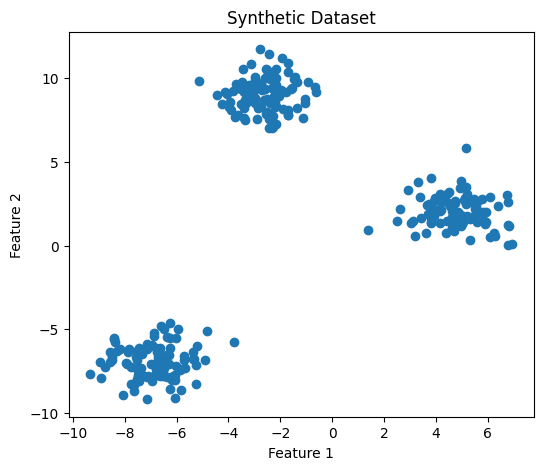

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Synthetic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Initializing Centroids

We randomly choose K examples from the dataset as the initial centroids.

In [4]:
K = 3

random_indices = np.random.choice(
    X.shape[0],
    K,
    replace= False
)

initial_centroids = X[random_indices]

initial_centroids

array([[ 4.05051408,  2.82277178],
       [-6.75933156, -6.36567076],
       [ 4.9208707 ,  1.35047016]])

## Finding the Closest Centroid

For every example, compute its distance to each centroid and assign it to the nearest one.

In [5]:
def find_closest_centroids(X, centroids):
    idx = []

    for i in range(X.shape[0]):
        distances = np.sum((X[i] - centroids) ** 2, axis=1)
        idx.append(np.argmin(distances))

    return np.array(idx)


## Computing New Centroids

Once every point has been assigned to a cluster, compute the mean position of all points within each cluster.

In [6]:
def compute_centroids(X, idx, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        centroids[k] = np.mean(X[k==idx], axis= 0)
    
    return centroids

## Running the K-Means Algorithm

We repeatedly alternate between:

1. Assignment Step
2. Update Step

until convergence or until a maximum number of iterations is reached.

In [7]:
def run_kmeans(X, initial_centroids, max_iters=10):
    centroids = initial_centroids
    K = centroids.shape[0]

    for _ in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        new_centroids = compute_centroids(X, idx, K)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, idx

## Training the Model

In [8]:
centroids, idx = run_kmeans(
    X,
    initial_centroids,
    max_iters=10
)

## Final Clustering Result

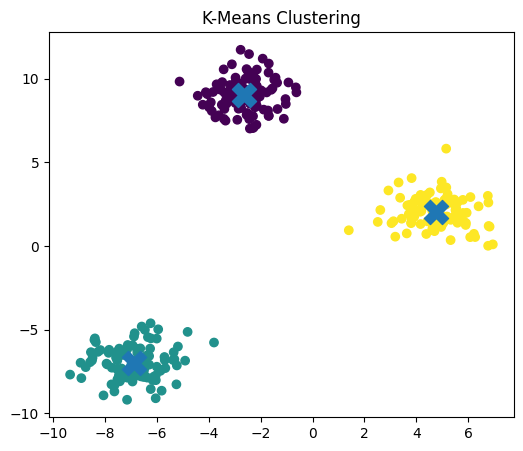

In [9]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=idx,
    cmap="viridis"
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300
)

plt.title("K-Means Clustering")
plt.show()


## Effect of Different Values of K

The choice of K strongly influences the clustering result.

We will experiment with several values of K and compare the resulting clusters.

## Evaluating Cluster Quality

To compare different values of K, we need a metric that quantifies how well the centroids represent the data.

We use the average squared distance between each point and its assigned centroid.

In [10]:
def compute_cost(X, centroids, idx):

    m = X.shape[0]

    cost = 0

    for i in range(m):
        centroid = centroids[idx[i]]
        cost += np.sum((X[i] - centroid) ** 2)

    return cost / m

## Effect of Different Values of K

The number of clusters, K, is a hyperparameter that must be chosen before running the algorithm.

A small value of K may force distinct groups into the same cluster, while a large value may unnecessarily split natural clusters.

We compare clustering results for several values of K.

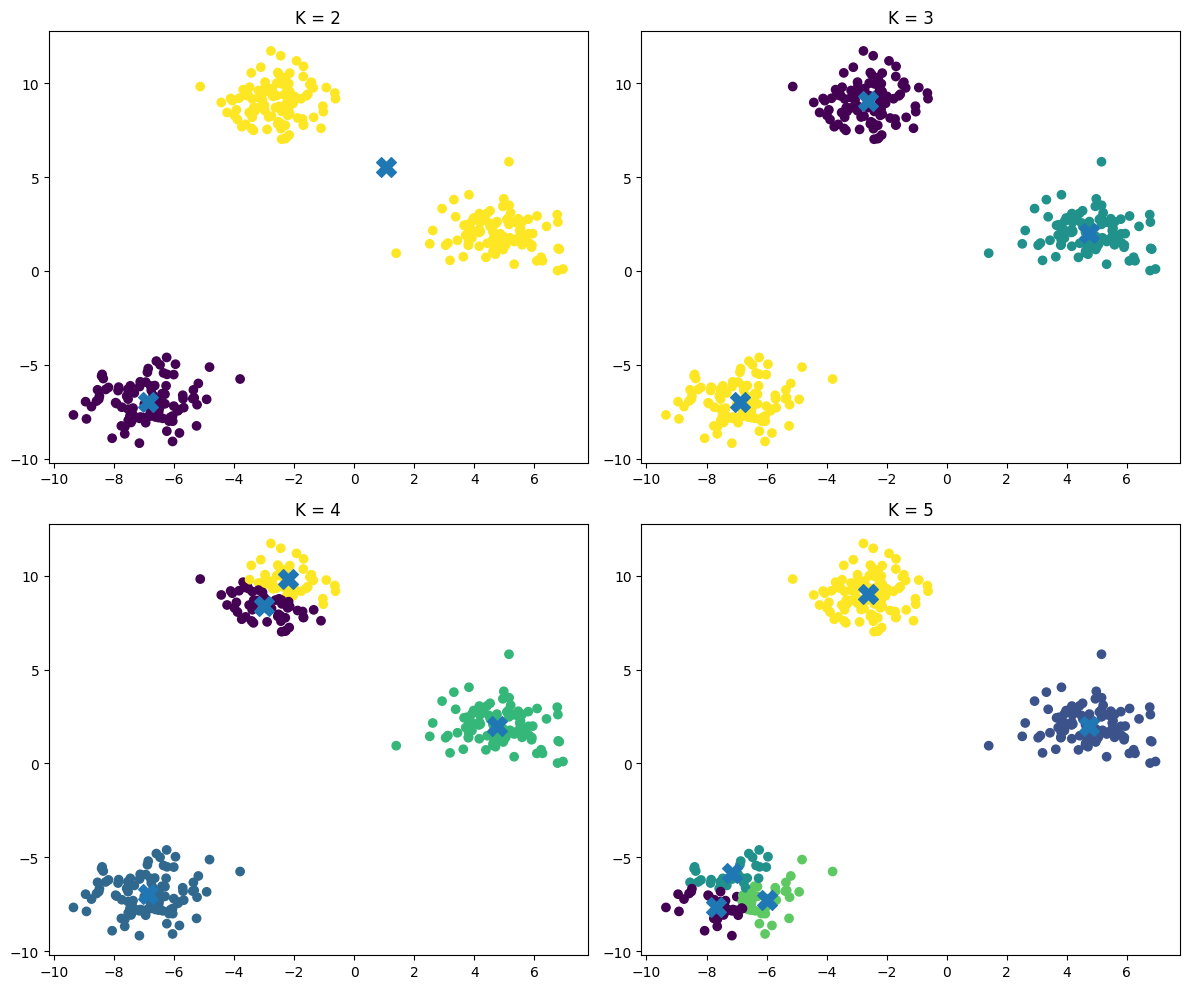

In [11]:
K_values = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, K in zip(axes.ravel(), K_values):

    random_indices = np.random.choice(
        X.shape[0],
        K,
        replace=False
    )

    initial_centroids = X[random_indices]

    centroids, idx = run_kmeans(
        X,
        initial_centroids,
        max_iters=10
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=idx,
        cmap="viridis"
    )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=200
    )

    ax.set_title(f"K = {K}")

plt.tight_layout()
plt.show()

### Analysis

- **K = 2** combines some naturally distinct groups into the same cluster.
- **K = 3** closely matches the underlying structure of the dataset.
- **K = 4** begins splitting existing clusters into smaller groups.
- **K = 5** introduces additional centroids that may not correspond to meaningful structure.

This demonstrates the importance of selecting an appropriate value for K.

## Elbow Method

A common strategy for choosing K is the Elbow Method.

The idea is to compute the clustering cost for multiple values of K and identify the point where increasing K yields diminishing improvements.

This point often appears as an "elbow" in the cost curve.

In [12]:
K_range = range(1, 11)

costs = []

for K in K_range:

    random_indices = np.random.choice(
        X.shape[0],
        K,
        replace=False
    )

    initial_centroids = X[random_indices]

    centroids, idx = run_kmeans(
        X,
        initial_centroids,
        max_iters=20
    )

    cost = compute_cost(
        X,
        centroids,
        idx
    )

    costs.append(cost)

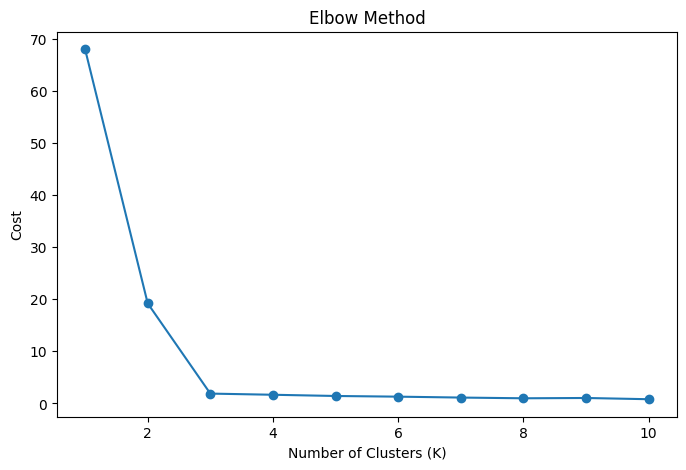

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    costs,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost")
plt.title("Elbow Method")

plt.show()

### Analysis

As K increases, the clustering cost decreases because each cluster contains fewer points and can fit the data more closely.

However, the improvement eventually becomes marginal.

The elbow point represents a balance between model simplicity and clustering performance.

For this dataset, the elbow appears around **K = 3**, which agrees with the visual inspection performed earlier.

## Computational Complexity

Let:

- m = number of examples
- n = number of features
- K = number of clusters
- T = number of iterations

During each iteration:

1. Assignment Step:
   - Compute distances from every point to every centroid
   - Complexity: O(mKn)

2. Update Step:
   - Recompute centroids
   - Complexity: O(mn)

Overall complexity:

$$
O(TmKn)
$$

K-Means is computationally efficient and scales well to large datasets, making it one of the most widely used clustering algorithms.

## Advantages of K-Means

- Simple and easy to implement
- Fast on large datasets
- Works well when clusters are compact and well separated
- Produces interpretable cluster centers
- Widely used in industry and research

## Limitations of K-Means

- Requires the number of clusters K beforehand
- Sensitive to initialization
- Sensitive to outliers
- Assumes approximately spherical clusters
- May converge to a local optimum rather than the global optimum

## Conclusion

In this notebook, we implemented the K-Means clustering algorithm from scratch and explored its behavior on a synthetic dataset.

Key takeaways:

- K-Means is an unsupervised learning algorithm used to group similar observations.
- The algorithm alternates between assigning examples to the nearest centroid and updating centroid positions.
- Cluster quality depends heavily on the choice of K.
- The Elbow Method provides a practical approach for selecting an appropriate number of clusters.
- Despite its limitations, K-Means remains one of the most popular clustering algorithms due to its simplicity and efficiency.